<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML(""))

In [5]:
# All needed imports
import numpy as np
import matplotlib.pyplot as plt


from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error

# for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

In [ ]:
print("Full dataset shape:", X_full.shape)
print("Full labels shape:", y_full.shape)

Full dataset shape: (70000, 28, 28)
Full labels shape: (70000,)


In [7]:
# Load Fashion-MNIST
(X_train_full, y_train_full), (X_test_original, y_test_original) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Combine the original train and test sets into one full dataset
X_full = np.concatenate([X_train_full, X_test_original], axis=0)
y_full = np.concatenate([y_train_full, y_test_original], axis=0)

In [10]:
# First split for the training set = 5/7
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full,
    y_full,
    test_size=2/7,
    random_state=42,
    stratify=y_full
)

# Second split for validation (1/7) and test set (1/7)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [11]:
# Scale pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_valid = X_valid.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
# Reshape to (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_valid = X_valid.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [13]:
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)
print("Test set shape:", X_test.shape)

Training set shape: (50000, 28, 28, 1)
Validation set shape: (10000, 28, 28, 1)
Test set shape: (10000, 28, 28, 1)


In [16]:
stacked_encoder = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
    layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    layers.Dense(32, activation="relu", kernel_initializer="he_normal")
], name="stacked_encoder")

In [19]:
# decoder as a mirror copy of the encoder
# activation function = sigmoid as this outpouts in the range (0,1), which is what I need for the output layer since I have scaled the pixels to (0,1)
stacked_decoder = keras.Sequential([
    keras.Input(shape=(32,)),
    layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape((28, 28, 1))
], name="stacked_decoder")

In [20]:
# combine to create the autoencoder
stacked_autoencoder = keras.Sequential([
    stacked_encoder,
    stacked_decoder
], name="stacked_autoencoder")

# compile using Adam optimizer and binary crossentropy loss function
stacked_autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy"
)

stacked_autoencoder.summary()

Model: "stacked_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stacked_encoder (Sequential)    │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_decoder (Sequential)    │ (None, 28, 28, 1)      │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Build the convolutional autoencoder
conv_autoencoder = keras.Sequential([

    # Input images have shape 28x28x1
    layers.Input(shape=(28, 28, 1)),

    # Encoder part
    # First convolutional layer:
    # learns 8 local image patterns using 3x3 filters.
    # padding="same" preserves the 28x28 spatial size.
    layers.Conv2D(
        filters=8,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    # First pooling layer:
    # reduces spatial size from 28x28 to 14x14.
    # padding="same" handles borders cleanly.
    layers.MaxPooling2D(
        pool_size=2,
        padding="same"
    ),

    # Second convolutional layer:
    # learns 16 higher-level local patterns.
    # spatial size remains 14x14 because padding="same".
    layers.Conv2D(
        filters=16,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    # Second pooling layer:
    # reduces spatial size from 14x14 to 7x7.
    layers.MaxPooling2D(
        pool_size=2,
        padding="same"
    ),

    # Decoder part
    # First transposed convolution:
    # upsamples from 7x7 to 14x14 using strides=2.
    layers.Conv2DTranspose(
        filters=16,
        kernel_size=3,
        strides=2,
        activation="relu",
        padding="same"
    ),

    # Second transposed convolution:
    # upsamples from 14x14 to 28x28 using strides=2.
    layers.Conv2DTranspose(
        filters=8,
        kernel_size=3,
        strides=2,
        activation="relu",
        padding="same"
    ),

    # Output layer:
    # produces one reconstructed grayscale image channel.
    # sigmoid is used because pixels are scaled to [0, 1].
    layers.Conv2D(
        filters=1,
        kernel_size=3,
        activation="sigmoid",
        padding="same"
    )
], name="convolutional_autoencoder")

In [22]:
# Compile the model
# Adam is a stable and efficient optimizer.
# Binary crossentropy is suitable because pixel values are normalized in [0, 1].
conv_autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy"
)

# Print the model architecture
conv_autoencoder.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 8)      │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Early stopping callback
# It monitors validation loss and stops training if improvement becomes too small.
early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.005,
    restore_best_weights=True
)

In [24]:
# Train stacked autoencoder
history_stacked = stacked_autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, X_valid),
    callbacks=[early_stopping_cb]
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.3079 - val_loss: 0.2889
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.2842 - val_loss: 0.2816
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2794 - val_loss: 0.2785
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.2770 - val_loss: 0.2768
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.2755 - val_loss: 0.2759
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.2744 - val_loss: 0.2750
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.2736 - val_loss: 0.2743
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.2729 - val_loss: 0.2738
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.2724 - val_loss: 0.2736
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2720 - val_loss: 0.2732


In [25]:
# Train convolutional autoencoder
history_conv = conv_autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, X_valid),
    callbacks=[early_stopping_cb]
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 37ms/step - loss: 0.2936 - val_loss: 0.2705
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - loss: 0.2666 - val_loss: 0.2644
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - loss: 0.2623 - val_loss: 0.2615
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - loss: 0.2602 - val_loss: 0.2601
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - loss: 0.2591 - val_loss: 0.2592
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - loss: 0.2584 - val_loss: 0.2586
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - loss: 0.2579 - val_loss: 0.2581
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - loss: 0.2574 - val_loss: 0.2577
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - loss: 0.2571 - val_loss: 0.2574
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - loss: 0.2568 - val_loss: 0.2571


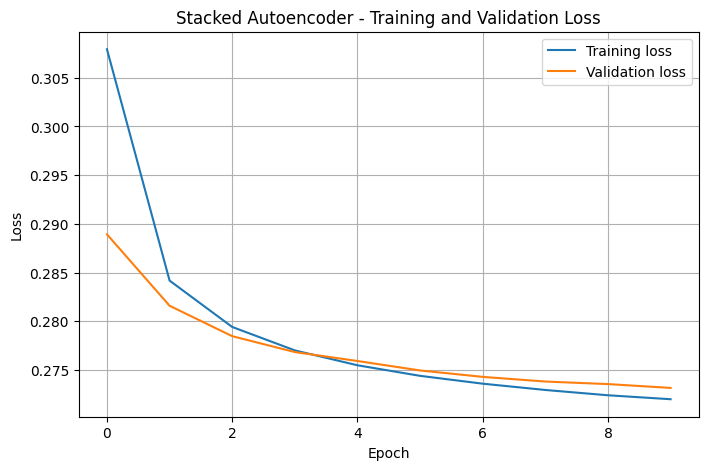

In [26]:
# Plot stacked autoencoder training history
plt.figure(figsize=(8, 5))
plt.plot(history_stacked.history["loss"], label="Training loss")
plt.plot(history_stacked.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stacked Autoencoder - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

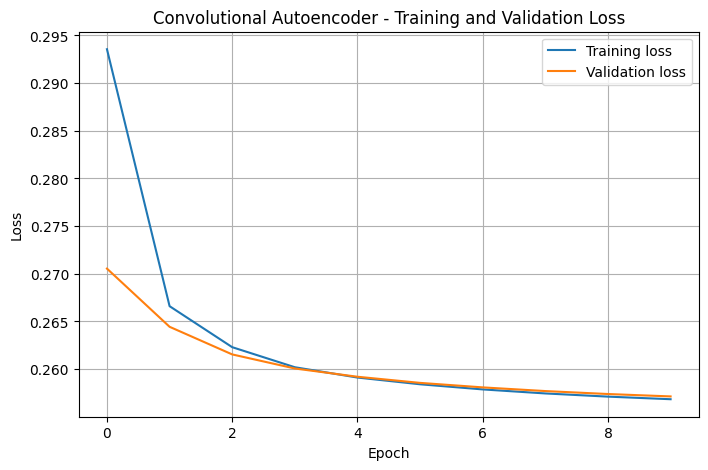

In [27]:
# Plot convolutional autoencoder training history
plt.figure(figsize=(8, 5))
plt.plot(history_conv.history["loss"], label="Training loss")
plt.plot(history_conv.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convolutional Autoencoder - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Reconstruct test images using the stacked autoencoder
stacked_reconstructions = stacked_autoencoder.predict(X_test)

# Reconstruct test images using the convolutional autoencoder
conv_reconstructions = conv_autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [29]:
# Compute MAE for stacked autoencoder
stacked_mae = mean_absolute_error(
    X_test.flatten(),
    stacked_reconstructions.flatten()
)

# Compute MAE for convolutional autoencoder
conv_mae = mean_absolute_error(
    X_test.flatten(),
    conv_reconstructions.flatten()
)

print("Stacked Autoencoder MAE:", stacked_mae)
print("Convolutional Autoencoder MAE:", conv_mae)

Stacked Autoencoder MAE: 0.054778482764959335
Convolutional Autoencoder MAE: 0.03612320125102997


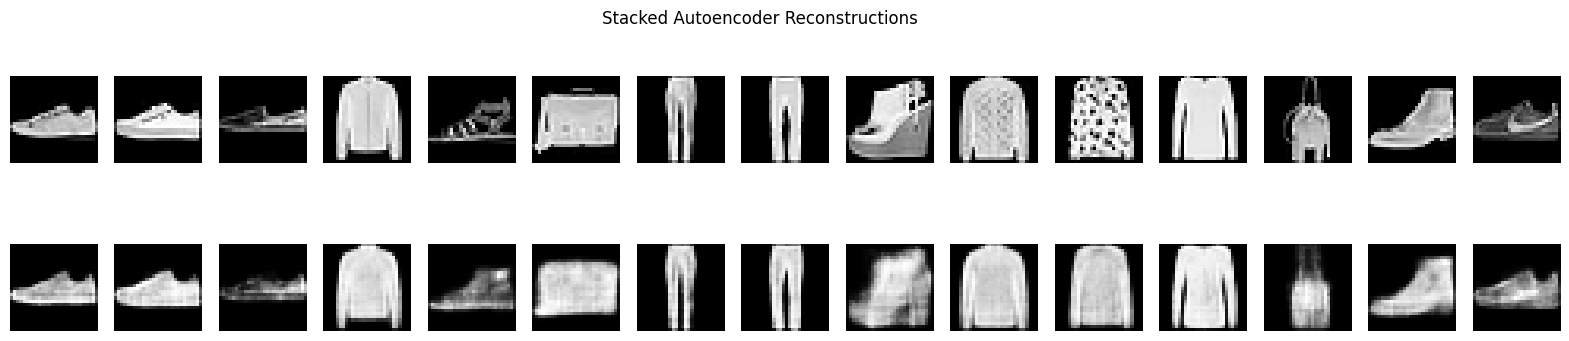

In [30]:
# Plot original and reconstructed images for the stacked autoencoder
plt.figure(figsize=(20, 4))

for i in range(15):

    # Original image
    plt.subplot(2, 15, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, 15, i + 16)
    plt.imshow(stacked_reconstructions[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Stacked Autoencoder Reconstructions")
plt.show()

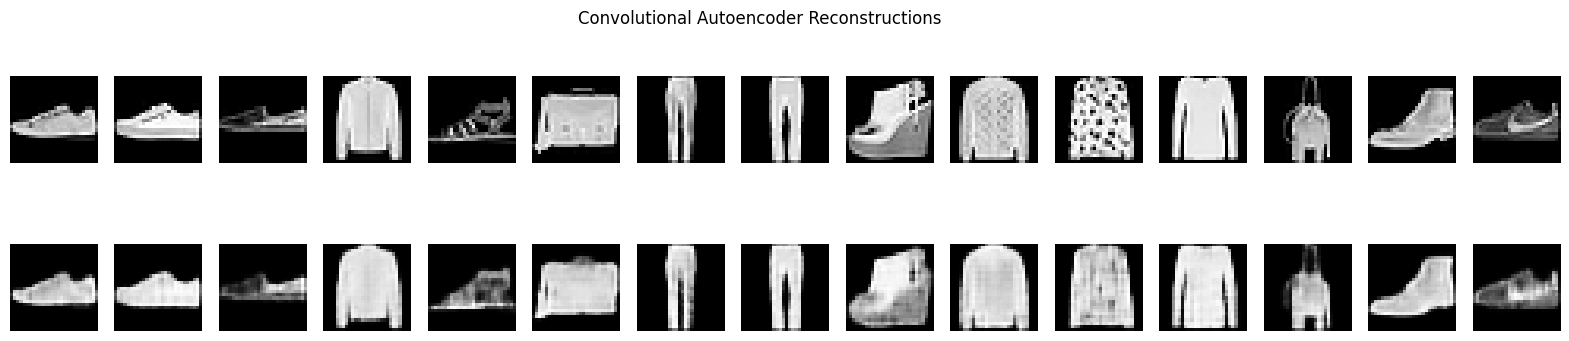

In [31]:
# Plot original and reconstructed images for the convolutional autoencoder
plt.figure(figsize=(20, 4))

for i in range(15):

    # Original image
    plt.subplot(2, 15, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, 15, i + 16)
    plt.imshow(conv_reconstructions[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Convolutional Autoencoder Reconstructions")
plt.show()

The convolutional autoencoder achieved lower reconstruction error and produced visually sharper reconstructed images compared to the stacked autoencoder. This is expected because convolutional layers preserve and learn spatial features of images more effectively than fully connected Dense layers, which flatten the input and lose spatial structure.

Problem 2

In [ ]:
# Load Fashion-MNIST
(X_train_full, y_train_full), _ = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


From publicly available information for the dataset we know
Labels

Each training and test example is assigned to one of the following labels:

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [ ]:
# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
# Keep only: 0 = T-shirt/top, 1 = Trouser & 2 = Pullover
mask = (
    (y_train_full == 0) |
    (y_train_full == 1) |
    (y_train_full == 2)
)

# Filter the dataset
X_train = X_train_full[mask]
y_train = y_train_full[mask]

# Scale pixel values from [0, 255] to [-1, 1]
X_train = X_train.astype("float32") / 127.5 - 1

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("Pixel min:", X_train.min())
print("Pixel max:", X_train.max())

print("Class distribution:", np.bincount(y_train))

X_train shape: (18000, 28, 28)
y_train shape: (18000,)
Pixel min: -1.0
Pixel max: 1.0
Class distribution: [6000 6000 6000]


In [ ]:
# Size of the random noise vector
noise_size = 32

# Build the Generator. It has two hidden layers, each with 128 and 256 units,
# Activation function ReLU and a He normal kernel initializer. It outputs a
# fully connected layer of a 784-dimensional vector with activation tanh, which
# is reshaped to a 28 by 28 pixels image.

generator = keras.Sequential([
    layers.Input(shape=(noise_size,)),

    layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        28 * 28,
        activation="tanh"
    ),

    # Reshape the 784 values into a 28x28 image
    layers.Reshape((28, 28))

], name="generator")

# Print model summary
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,736 (932.56 KB)

 Trainable params: 238,736 (932.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the Discriminator
discriminator = keras.Sequential([

    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        128,
        activation="relu",
        kernel_initializer="he_normal"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
], name="discriminator")

# Print model summary
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)